In [7]:


!nvidia-smi

Sat Jul  4 11:42:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Install the Ultralytics Package

In [8]:
!pip install ultralytics

# Import All the Requried Libraries

In [9]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.0/112.6 GB disk)


In [10]:
from ultralytics import YOLO
from IPython.display import Image

model = YOLO("yolo26n.pt")

# Dataset Downlode

In [16]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="trta6GNa9BxIphg4DPfG")
project = rf.workspace("abdullahs-workspace-rcwes").project("things-oakf2-wuhk9")
version = project.version(3)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to things-3 in yolo26:: 100%|██████████| 30178/30178 [00:07<00:00, 4018.45it/s] 


# Train YOLO26 Model on a Custom Dataset

In [17]:
!yolo task = detect mode = train data = {dataset.location}/data.yaml model = '/content/yolo26n.pt' epochs = 50 imgsz = 640

'/content/things-3'

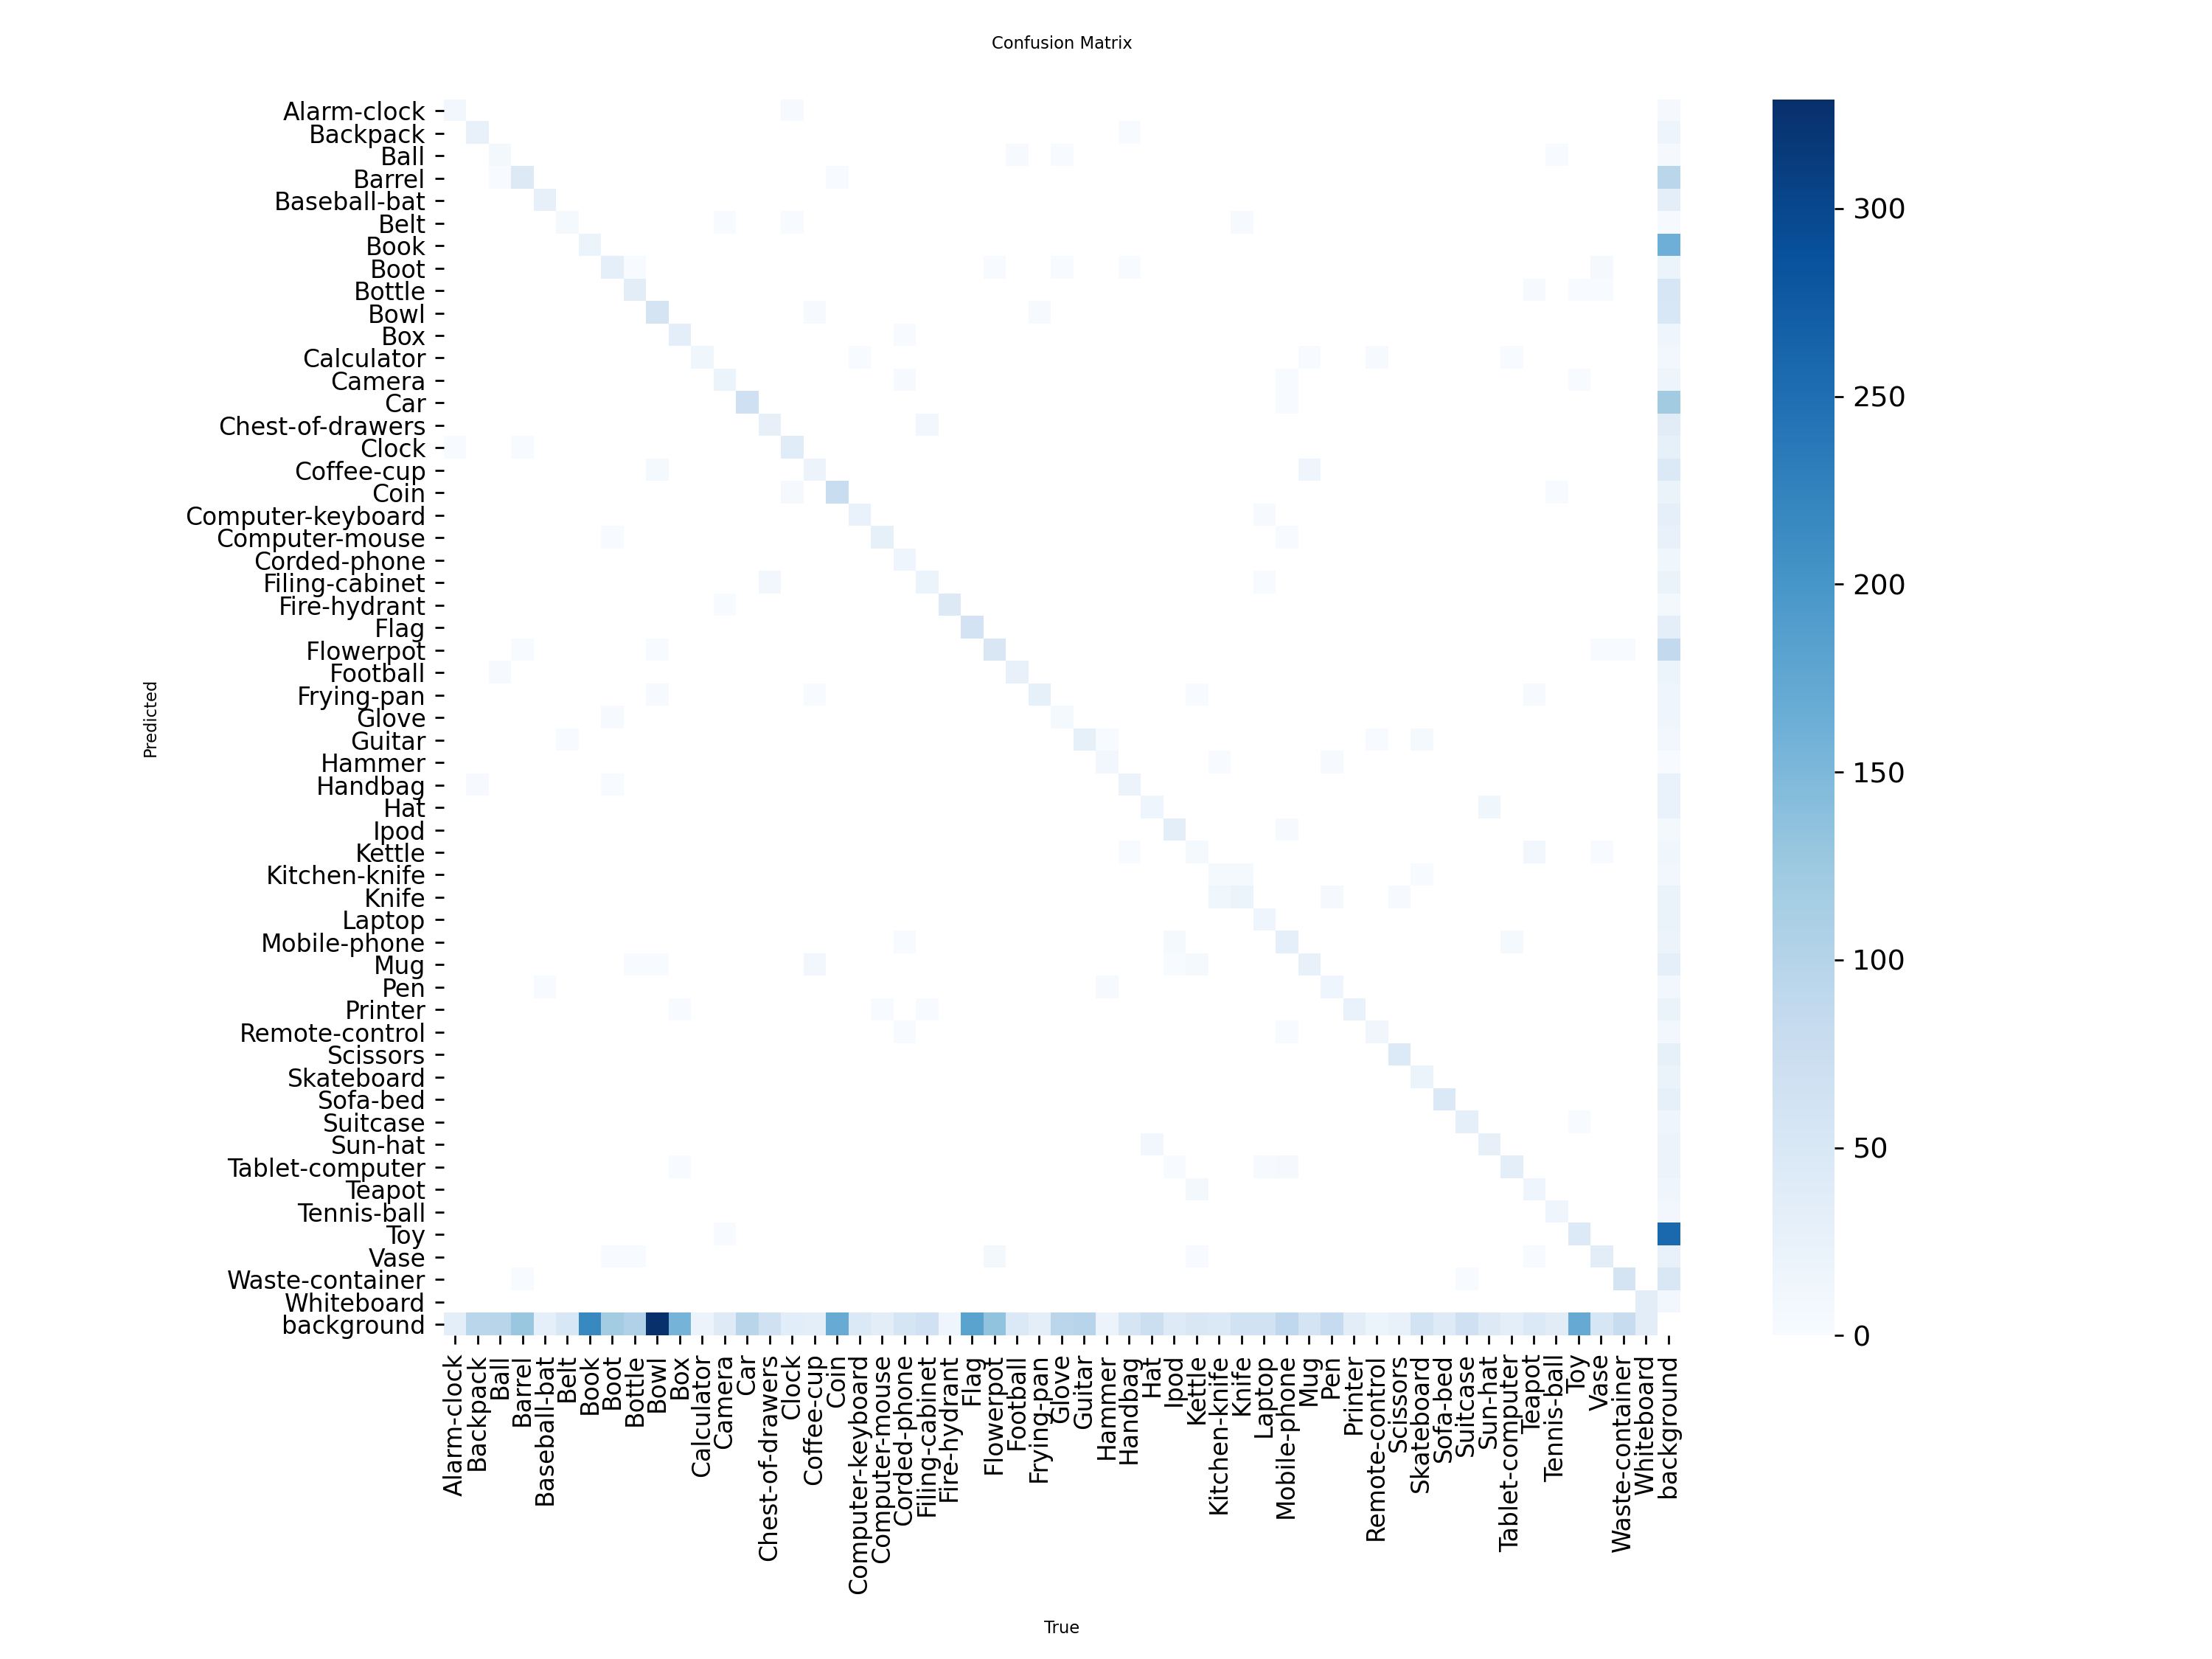

In [19]:

Image("/content/runs/detect/train/confusion_matrix.png", width=600)

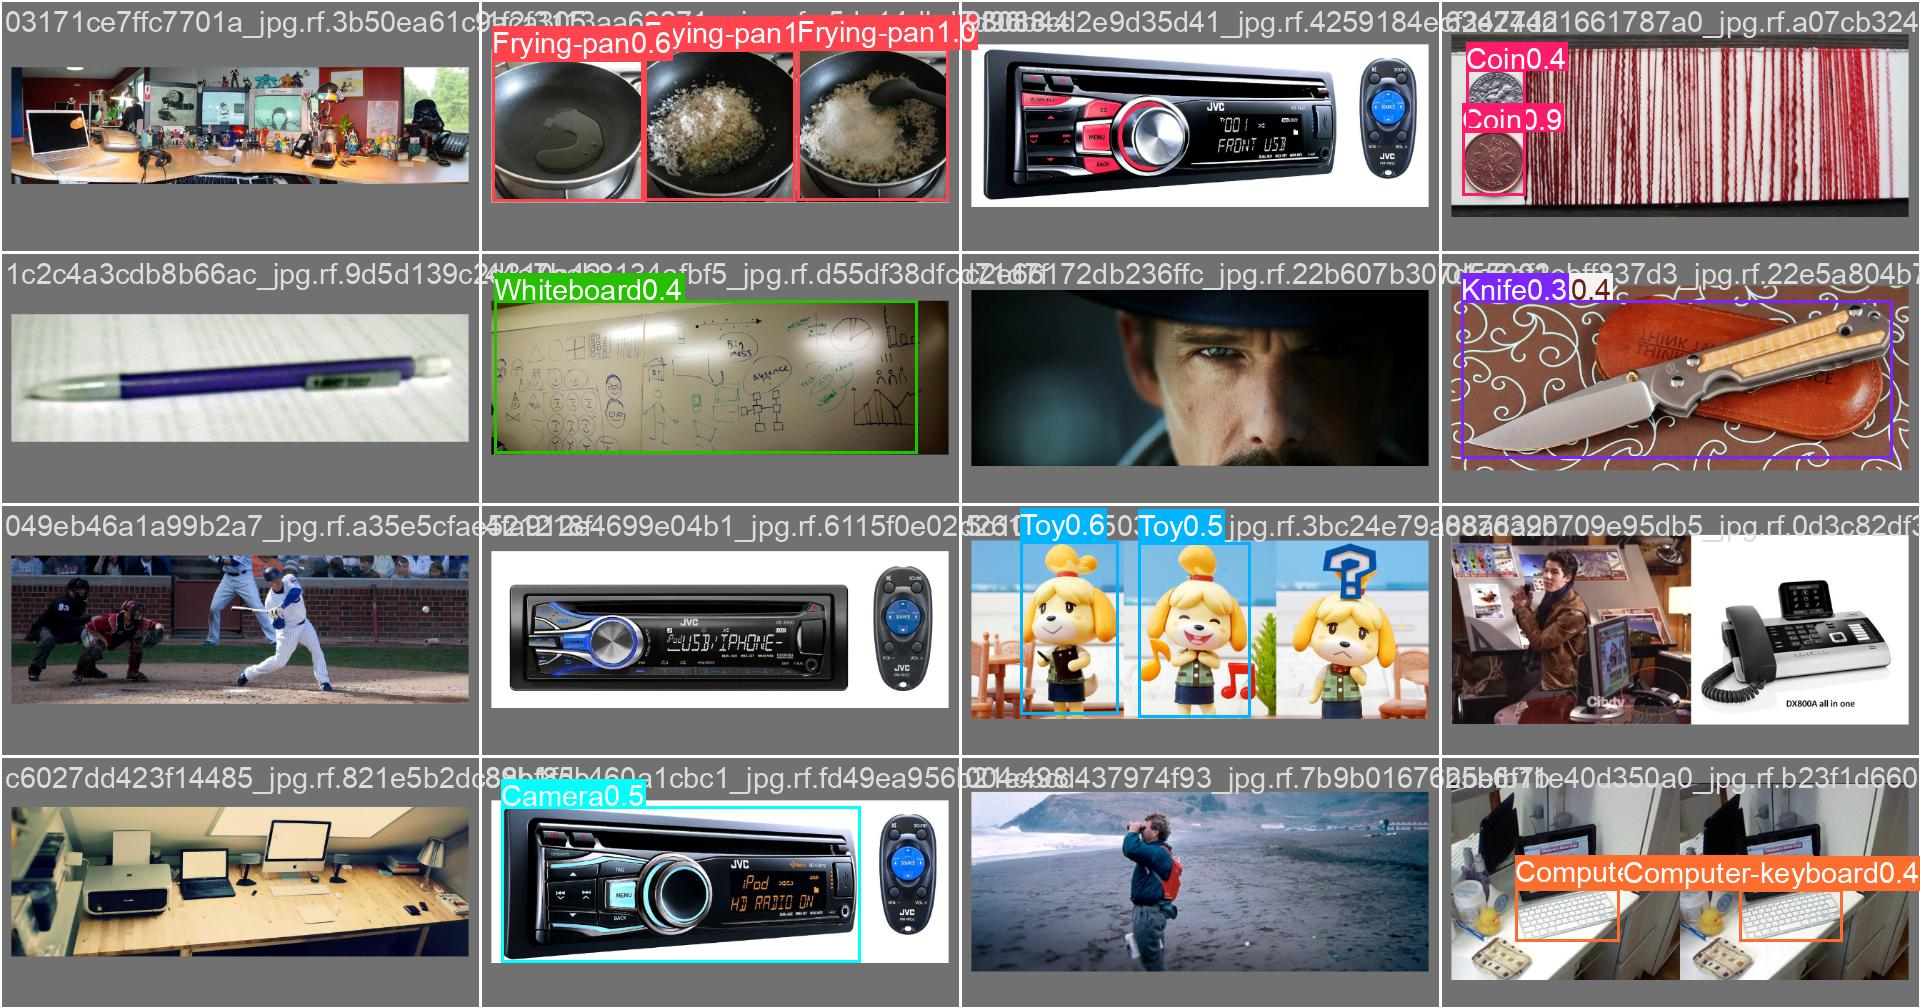

In [26]:
Image("/content/runs/detect/train/val_batch0_pred.jpg", width=600)

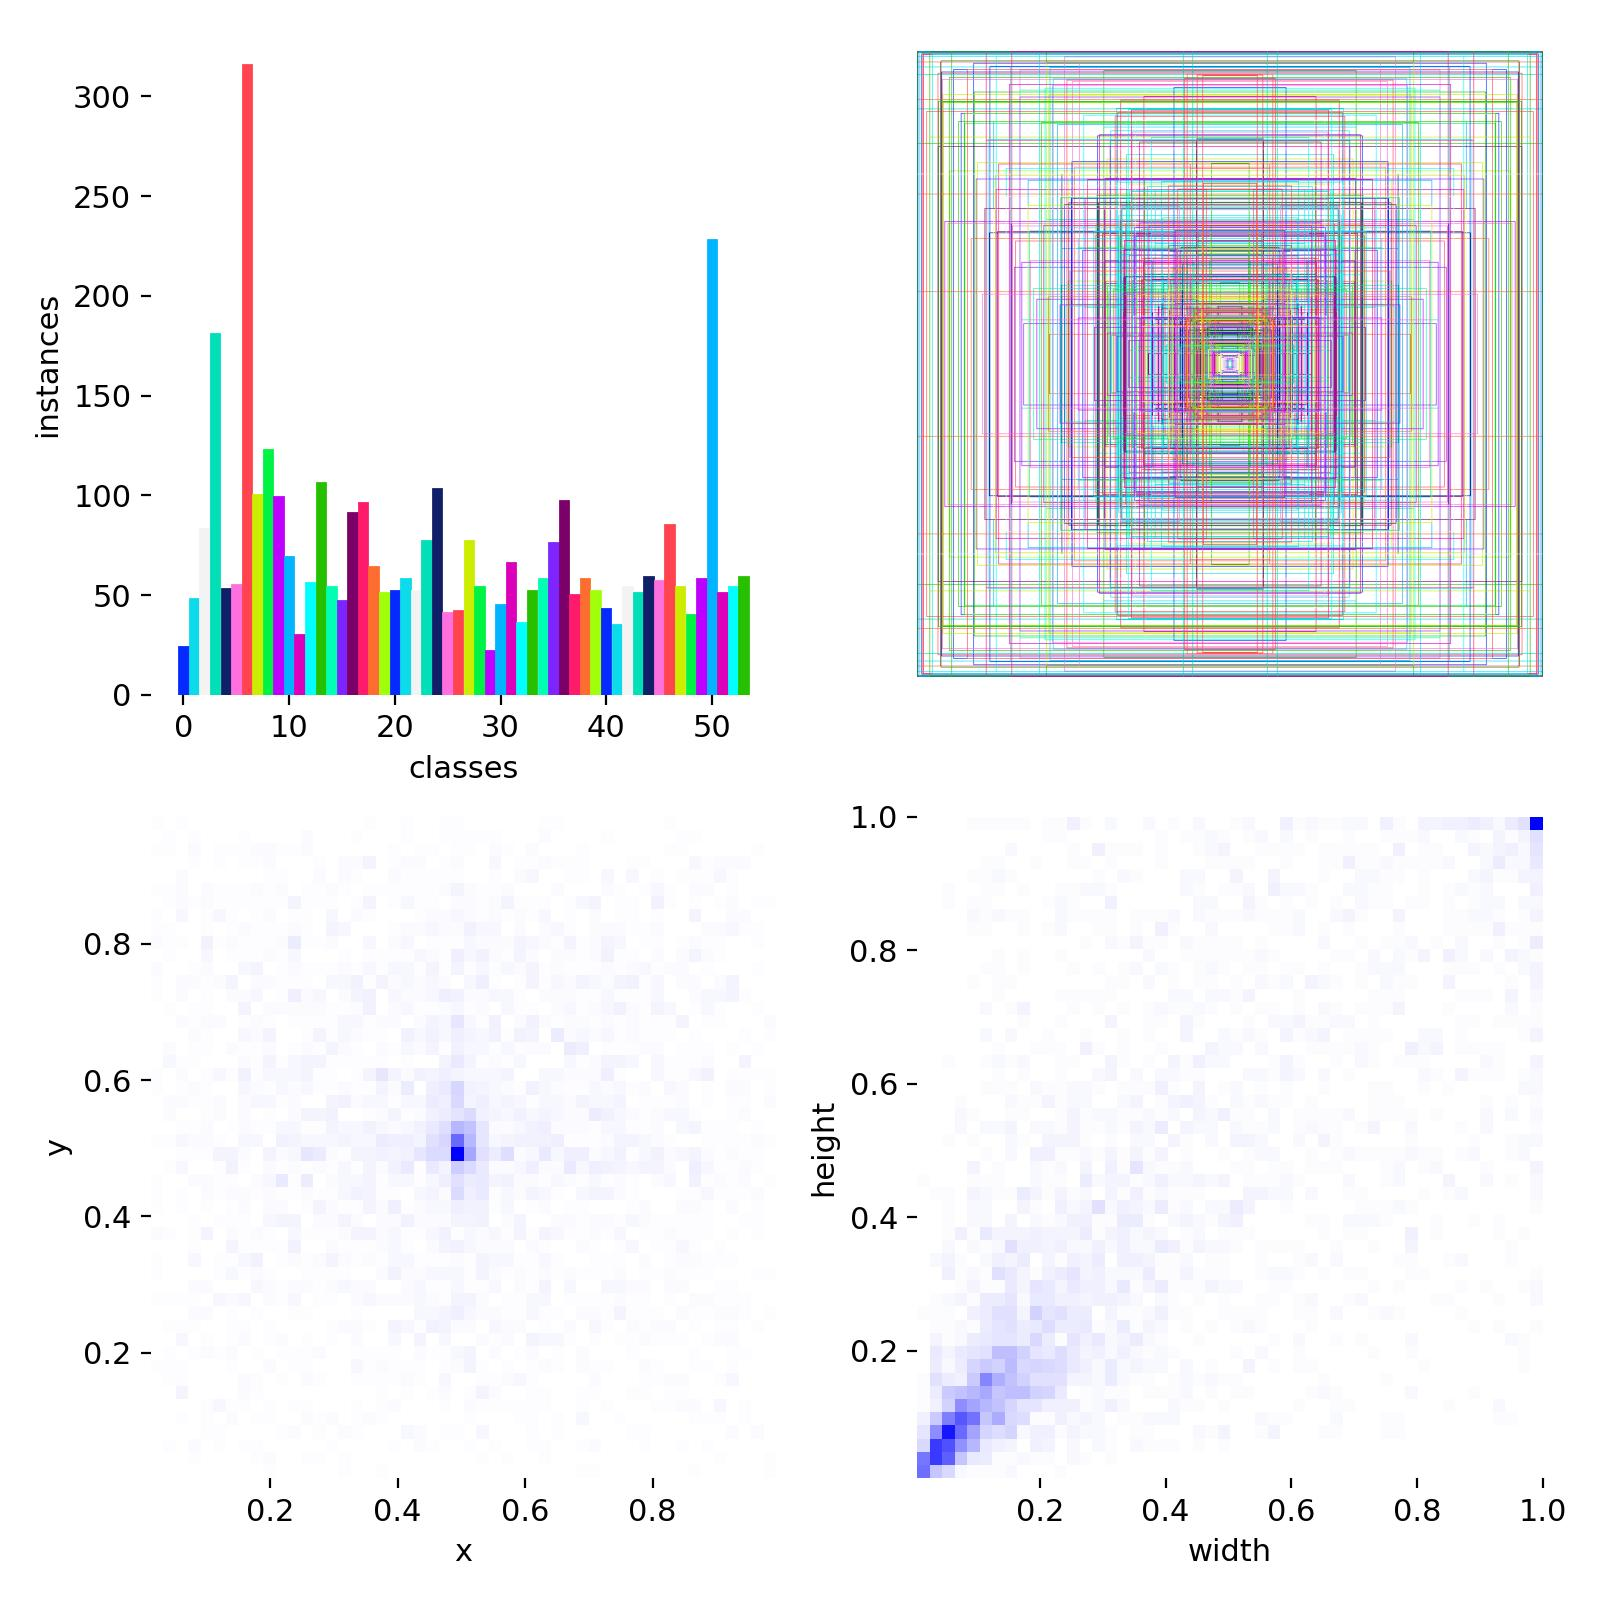

In [20]:

Image("/content/runs/detect/train/labels.jpg", width=600)

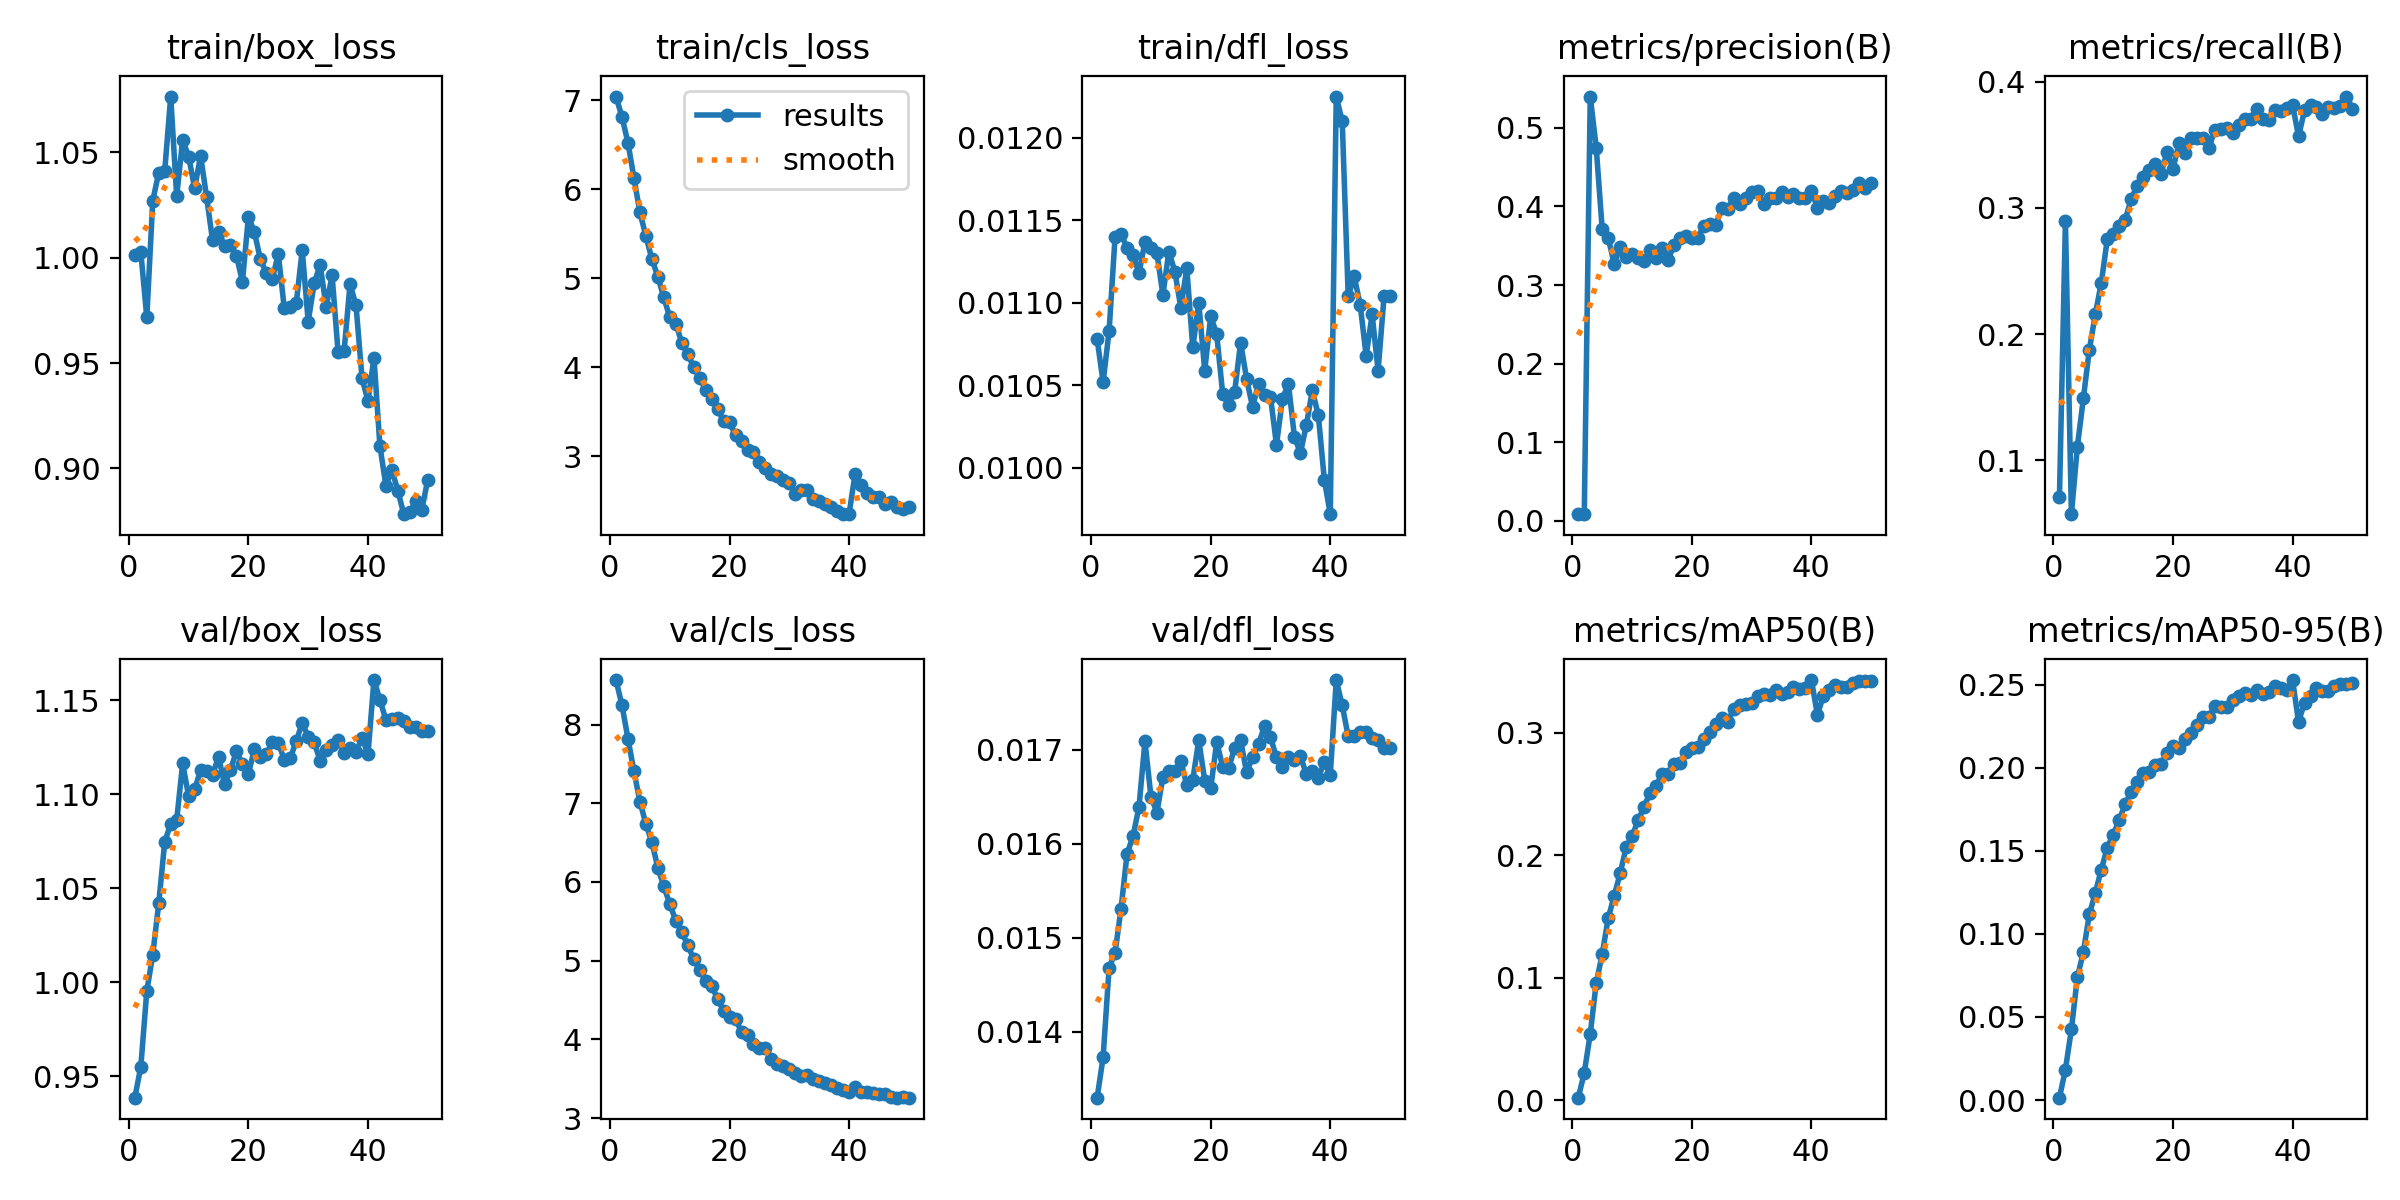

In [21]:
Image("/content/runs/detect/train/results.png", width=600)

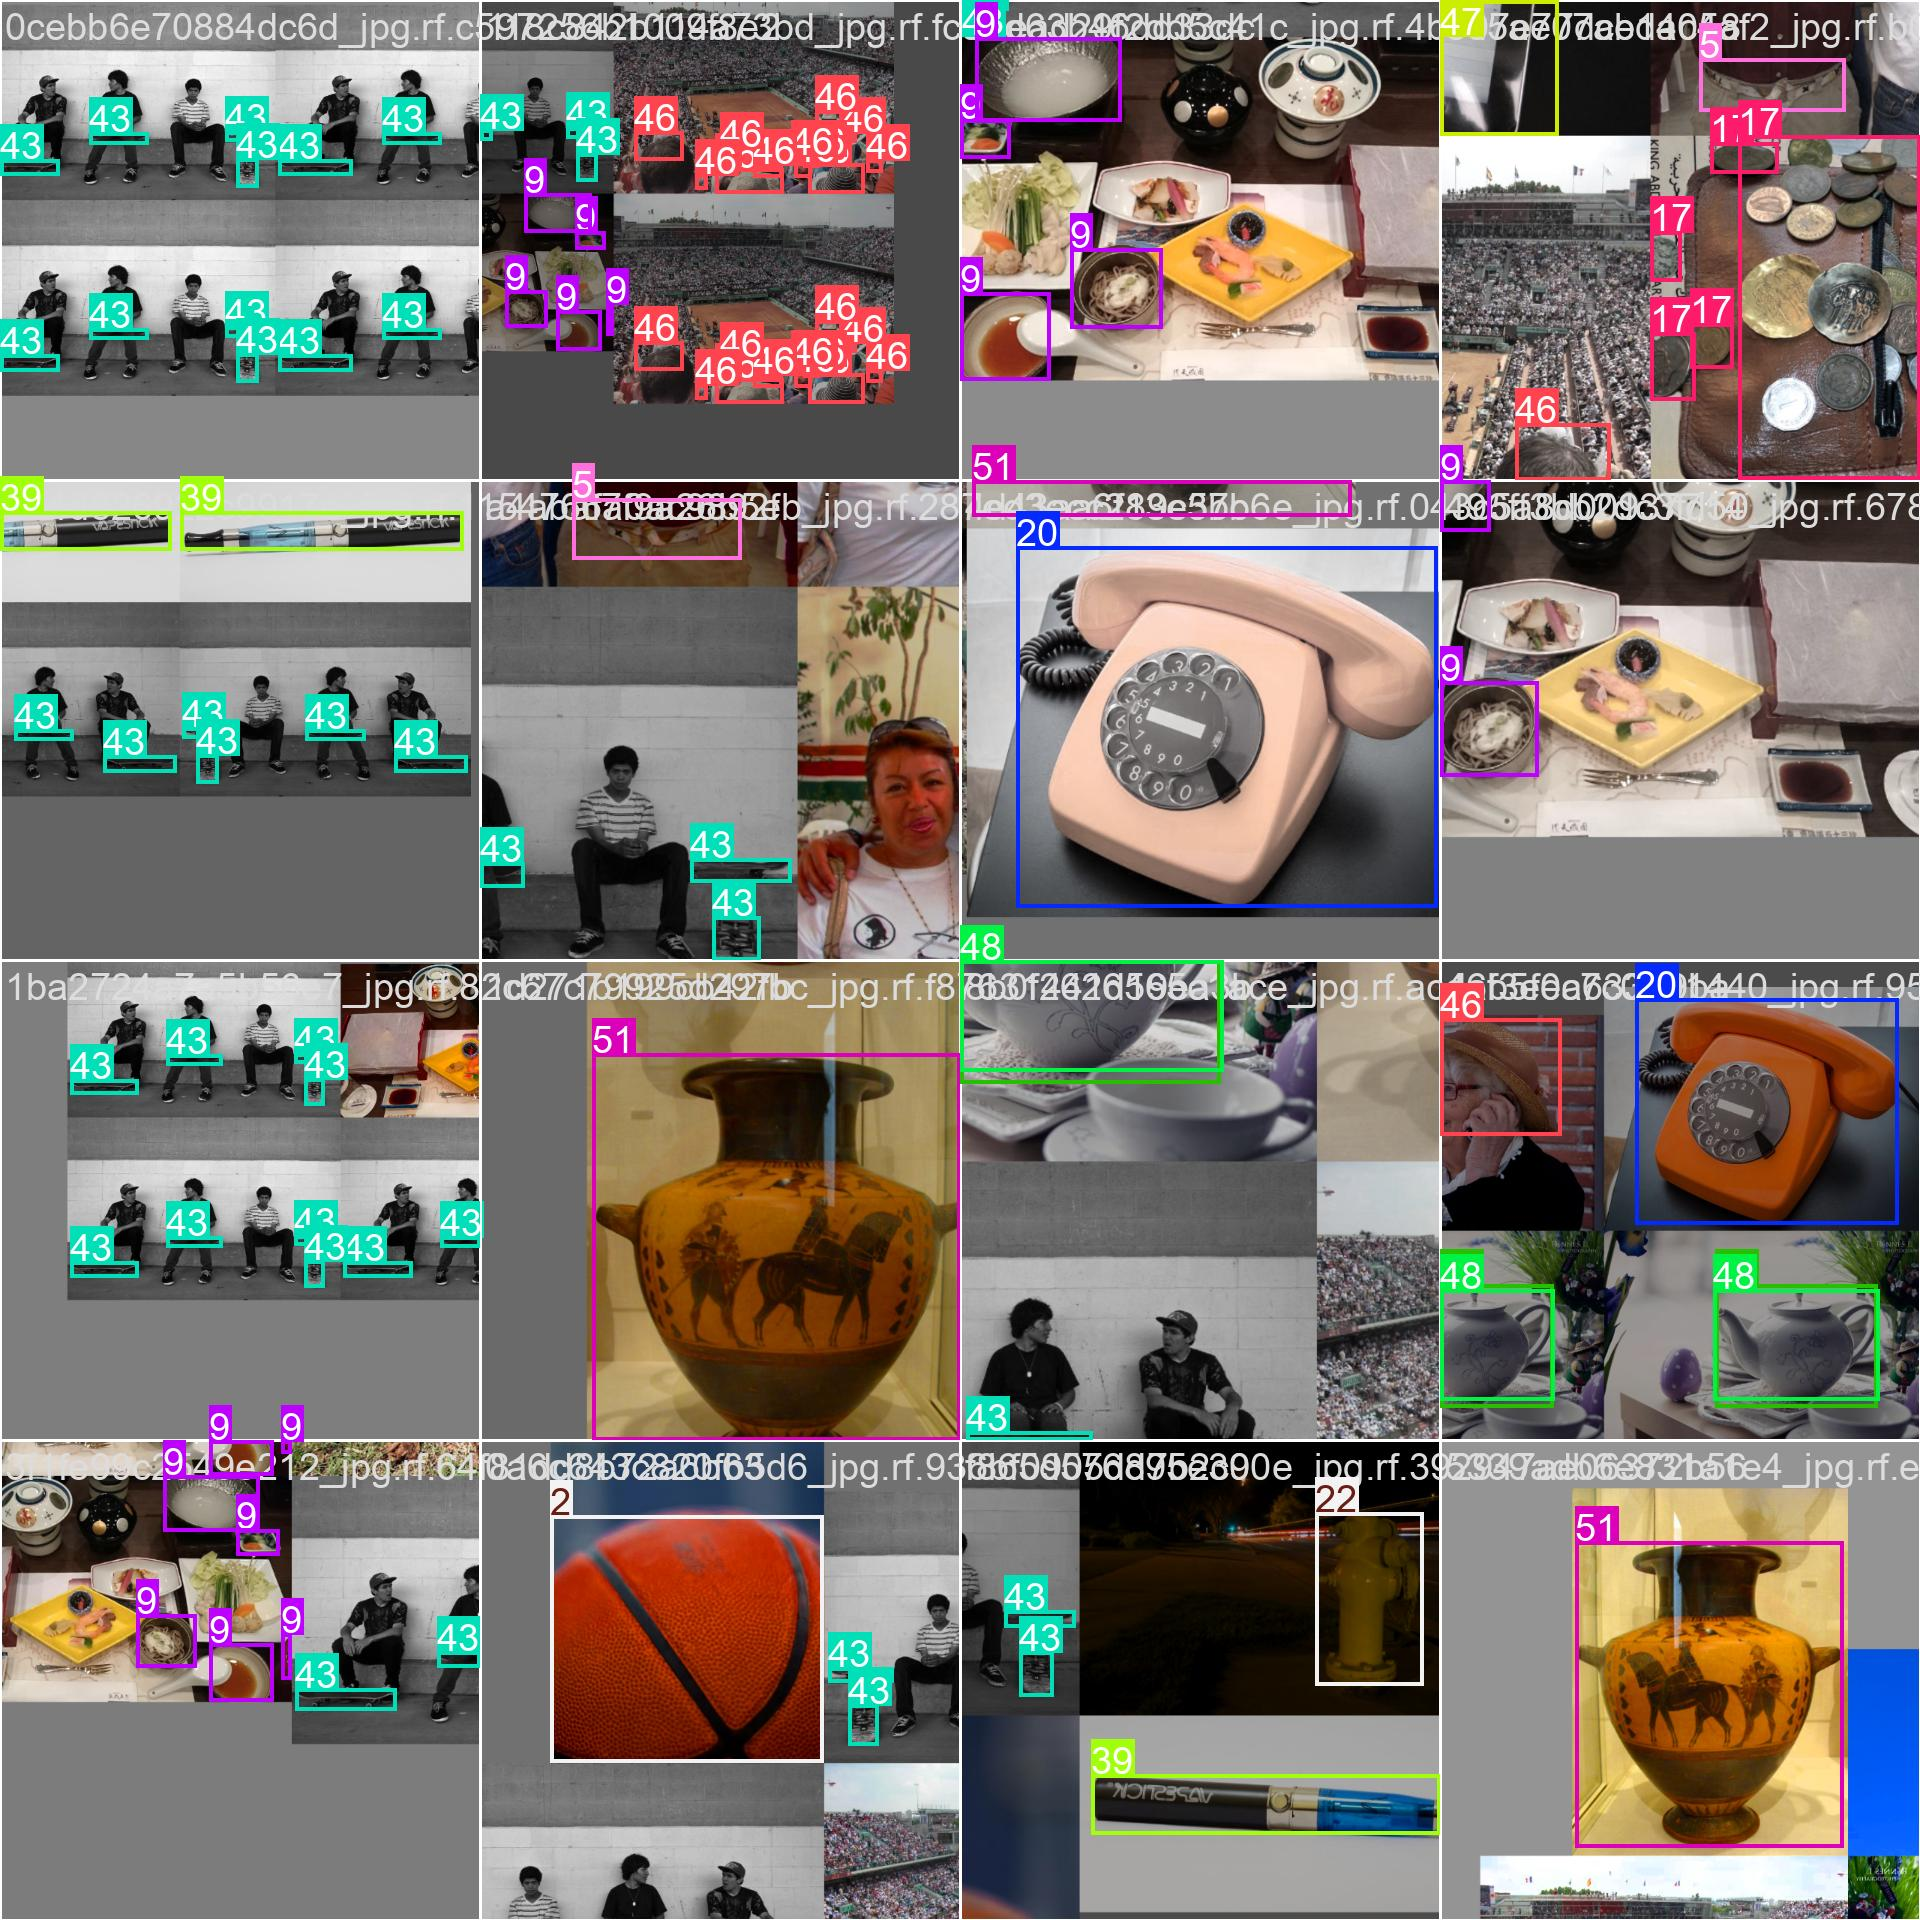

In [22]:

Image("/content/runs/detect/train/train_batch0.jpg", width=600)

# Validate Fine-Tuned Model

In [23]:
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,385,366 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2048.7±661.3 MB/s, size: 108.9 KB)
val: Scanning /content/things-3/valid/labels.cache... 3017 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3017/3017 342.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 189/189 5.7it/s 33.2s
                   all       3017       5673       0.42      0.381      0.342      0.252
           Alarm-clock         28         41       0.52      0.291       0.34      0.255
              Backpack         60        122      0.498      0.284      0.265       0.12
                  Ball         58        105      0.242     0.0729     0.0855     0.0613
                Barrel         54        172      0.241      0.286      0.142     0.0992
          Baseball-bat         52    

In [24]:
!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,385,366 parameters, 0 gradients, 5.2 GFLOPs

image 1/2113 /content/things-3/test/images/0002c799b0cd7412_jpg.rf.ff8d3e289f6991f1c2a649c78a893fc1.jpg: 448x640 1 Whiteboard, 115.8ms
image 2/2113 /content/things-3/test/images/000d13275f39a218_jpg.rf.5b3c4091981ed300efa0f03523eb872d.jpg: 480x640 (no detections), 101.9ms
image 3/2113 /content/things-3/test/images/0012ca60c774547e_jpg.rf.66147a614ecb41a74e535d4d3a850f7e.jpg: 352x640 (no detections), 84.7ms
image 4/2113 /content/things-3/test/images/0012da0757224c51_jpg.rf.91ea3acd9c2cfdddc83544cc5eac0c7b.jpg: 448x640 4 Bottles, 11.5ms
image 5/2113 /content/things-3/test/images/0017b9279fbb80af_jpg.rf.6bc3678d896cd21c9868fd57edb7d93d.jpg: 640x448 1 Hat, 1 Sun-hat, 68.3ms
image 6/2113 /content/things-3/test/images/00188d7e8bd9686a_jpg.rf.d074b06ab3b29d1efeec57f8b67e35a3.jpg: 480x640 (no detections), 11.4ms
image 7/2113 /con

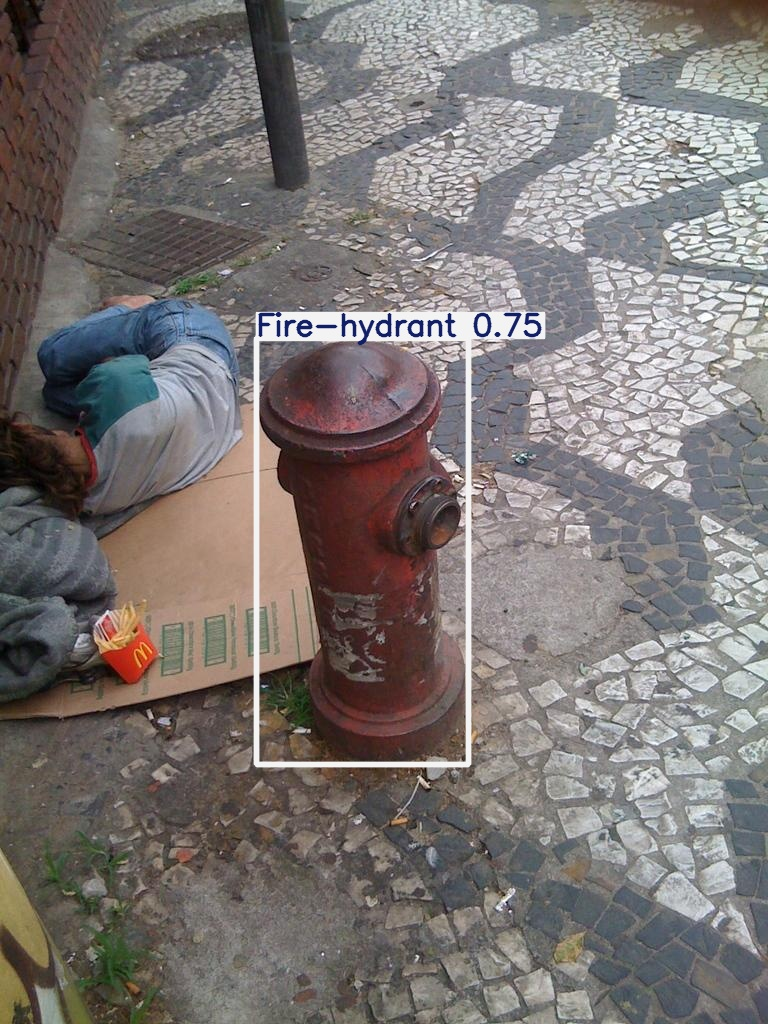

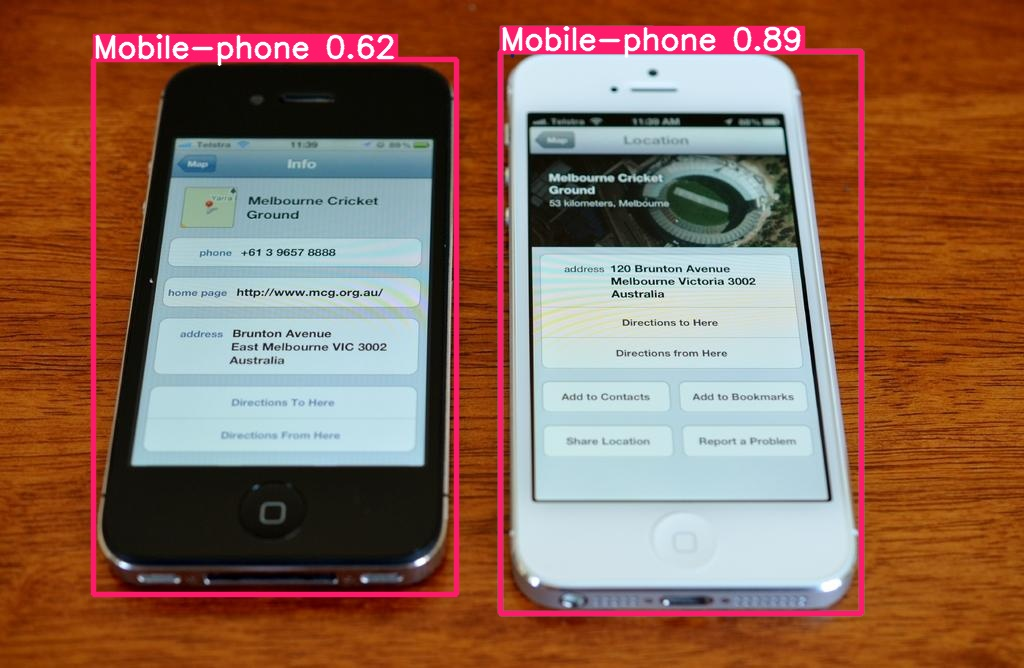

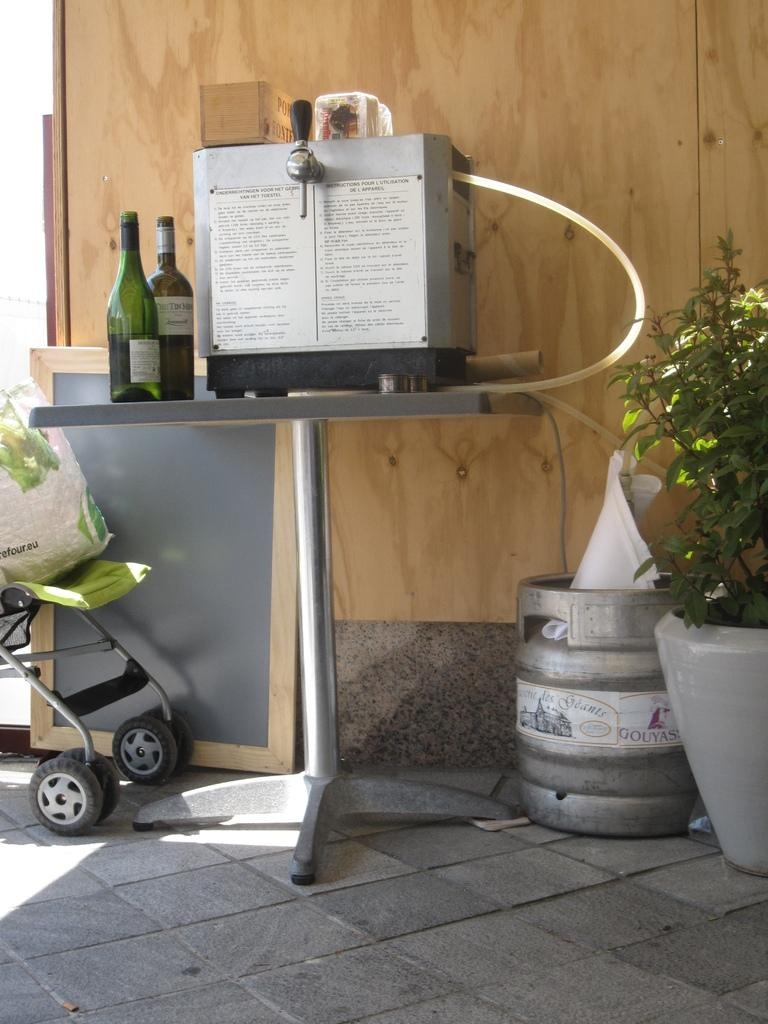

In [25]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
    display(IPyImage(filename=img, width=600))
    print("\n")